In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

In [3]:
X = np.load(DATA_PROCESSED / "X_windows.npy")

sample_dates = np.load(
    DATA_PROCESSED / "sample_dates.npy",
    allow_pickle=True
)

sample_tickers = np.load(
    DATA_PROCESSED / "sample_tickers.npy",
    allow_pickle=True
)

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

sample_dates = pd.to_datetime(sample_dates)
returns.index = pd.to_datetime(returns.index)

X.shape, sample_dates.shape, sample_tickers.shape

((70080, 60, 6), (70080,), (70080,))

In [5]:
WINDOW = 60
HORIZON = 10

LATENT_DIM = 8

D_MODEL = 32
N_HEADS = 4
STOCK_LAYERS = 1
D_FF = 64
DROPOUT = 0.1

BATCH_SIZE = 64
N_EPOCHS = 50
PATIENCE = 8

TRAIN_RATIO = 0.7
VAL_RATIO_WITHIN_TRAIN = 0.8

REBALANCE_EVERY = 10
LONG_Q = 0.8
SHORT_Q = 0.2
TRANSACTION_COST = 0.001

SEED = 42

In [6]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [10]:
class SupervisedCNNVAE(nn.Module):
    def __init__(self, n_features, window, latent_dim=8):
        super().__init__()

        self.n_features = n_features
        self.window = window
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv1d(n_features, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, n_features, window)
            encoded = self.encoder_conv(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.encoded_dim = encoded.numel()

        self.fc_mu = nn.Linear(self.encoded_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoded_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.encoded_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                64, 32,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                32, 16,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                16, n_features,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
        )

        self.predictor = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.encoded_shape)

        x_recon = self.decoder_conv(h)

        return x_recon[:, :, :self.window]

    def predict(self, z):
        return self.predictor(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode(z)
        y_pred = self.predict(z)

        return x_recon, y_pred, mu, logvar

In [16]:
checkpoint = torch.load(
    MODELS_DIR / "supervised_cnn_vae.pt",
    map_location="cpu",
    weights_only=False
)
checkpoint.keys()

dict_keys(['model_state_dict', 'n_features', 'window', 'latent_dim', 'beta', 'gamma', 'horizon', 'y_mean', 'y_std', 'history'])

In [17]:
n_samples, window, n_features = X.shape

vae_encoder = SupervisedCNNVAE(
    n_features=n_features,
    window=window,
    latent_dim=checkpoint["latent_dim"]
)

vae_encoder.load_state_dict(
    checkpoint["model_state_dict"]
)

vae_encoder.eval()

SupervisedCNNVAE(
  (encoder_conv): Sequential(
    (0): Conv1d(6, 16, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=512, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=512, out_features=8, bias=True)
  (fc_decode): Linear(in_features=8, out_features=512, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 6, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
  )
  (predictor): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_

In [18]:
for param in vae_encoder.parameters():
    param.requires_grad = False

In [19]:
meta_df = pd.DataFrame({
    "date": sample_dates,
    "ticker": sample_tickers,
    "idx": np.arange(len(sample_dates))
})

meta_df.head()

,date,ticker,idx
0,2015-09-21,AAPL,0
1,2015-09-22,AAPL,1
2,2015-09-23,AAPL,2
3,2015-09-24,AAPL,3
4,2015-09-25,AAPL,4


In [20]:
tickers = sorted(meta_df["ticker"].unique())

date_counts = meta_df.groupby("date")["ticker"].nunique()

valid_dates = date_counts[
    date_counts == len(tickers)
].index

len(valid_dates), len(tickers)

(2336, 30)

In [21]:
future_returns = pd.DataFrame(
    0.0,
    index=returns.index,
    columns=returns.columns
)

for h in range(1, HORIZON + 1):
    future_returns += returns.shift(-h)

In [22]:
X_market_list = []
y_market_list = []
market_dates = []

for date in valid_dates:
    g = meta_df[meta_df["date"] == date].copy()
    g = g.set_index("ticker").loc[tickers]

    indices = g["idx"].values

    X_date = X[indices]  # (n_stocks, window, n_features)

    y_date = future_returns.loc[date, tickers].values.astype(np.float32)

    if np.isnan(X_date).any():
        continue

    if np.isnan(y_date).any():
        continue

    X_market_list.append(X_date)
    y_market_list.append(y_date)
    market_dates.append(date)

X_market = np.stack(X_market_list).astype(np.float32)
y_market = np.stack(y_market_list).astype(np.float32)
market_dates = pd.to_datetime(np.array(market_dates))

X_market.shape, y_market.shape, market_dates.shape

((2326, 30, 60, 6), (2326, 30), (2326,))

In [23]:
all_dates = np.sort(market_dates.unique())

split_date = all_dates[int(TRAIN_RATIO * len(all_dates))]

train_full_mask = market_dates < split_date
test_mask = market_dates >= split_date

train_dates = np.sort(market_dates[train_full_mask].unique())

val_start = train_dates[
    int(VAL_RATIO_WITHIN_TRAIN * len(train_dates))
]

train_mask = train_full_mask & (market_dates < val_start)
val_mask = train_full_mask & (market_dates >= val_start)

print("Train:", market_dates[train_mask].min(), "->", market_dates[train_mask].max())
print("Val:", market_dates[val_mask].min(), "->", market_dates[val_mask].max())
print("Test:", market_dates[test_mask].min(), "->", market_dates[test_mask].max())

Train: 2015-09-21 00:00:00 -> 2020-11-18 00:00:00
Val: 2020-11-19 00:00:00 -> 2022-03-08 00:00:00
Test: 2022-03-09 00:00:00 -> 2024-12-16 00:00:00


In [24]:
def compute_market_latents(
    vae_encoder,
    X_market,
    batch_size=512
):
    """
    X_market:
        (n_dates, n_stocks, window, n_features)

    output:
        Z_market:
        (n_dates, n_stocks, latent_dim)
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    vae_encoder = vae_encoder.to(device)
    vae_encoder.eval()

    n_dates, n_stocks, window, n_features = X_market.shape

    X_flat = X_market.reshape(
        n_dates * n_stocks,
        window,
        n_features
    )

    # CNN encoder input: (batch, n_features, window)
    X_flat = np.transpose(
        X_flat,
        (0, 2, 1)
    ).astype(np.float32)

    Z_list = []

    with torch.no_grad():
        for start in range(0, len(X_flat), batch_size):
            end = start + batch_size

            xb = torch.tensor(
                X_flat[start:end],
                dtype=torch.float32
            ).to(device)

            mu, logvar = vae_encoder.encode(xb)

            Z_list.append(
                mu.cpu().numpy()
            )

    Z_flat = np.concatenate(Z_list, axis=0)

    Z_market = Z_flat.reshape(
        n_dates,
        n_stocks,
        -1
    )

    return Z_market.astype(np.float32)

In [25]:
Z_market = compute_market_latents(
    vae_encoder=vae_encoder,
    X_market=X_market,
    batch_size=512
)

Z_market.shape

(2326, 30, 8)

In [26]:
y_mean = y_market[train_mask].mean()
y_std = y_market[train_mask].std()

y_scaled = (y_market - y_mean) / (y_std + 1e-8)

y_scaled.mean(), y_scaled.std()

(np.float32(-0.020226331), np.float32(1.0366304))

In [27]:
z_mean = Z_market[train_mask].mean(axis=(0, 1), keepdims=True)
z_std = Z_market[train_mask].std(axis=(0, 1), keepdims=True)

Z_scaled = (Z_market - z_mean) / (z_std + 1e-8)

Z_scaled.shape

(2326, 30, 8)

In [28]:
class LatentMarketDataset(Dataset):
    def __init__(self, Z, y, dates):
        self.Z = torch.tensor(Z, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.dates = dates

    def __len__(self):
        return len(self.Z)

    def __getitem__(self, idx):
        return self.Z[idx], self.y[idx]

In [29]:
train_dataset = LatentMarketDataset(
    Z_scaled[train_mask],
    y_scaled[train_mask],
    market_dates[train_mask]
)

val_dataset = LatentMarketDataset(
    Z_scaled[val_mask],
    y_scaled[val_mask],
    market_dates[val_mask]
)

test_dataset = LatentMarketDataset(
    Z_scaled[test_mask],
    y_scaled[test_mask],
    market_dates[test_mask]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [30]:
class LatentStockAttentionModel(nn.Module):
    def __init__(
        self,
        latent_dim,
        d_model=32,
        n_heads=4,
        stock_layers=1,
        d_ff=64,
        dropout=0.1
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            latent_dim,
            d_model
        )

        stock_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.stock_encoder = nn.TransformerEncoder(
            stock_encoder_layer,
            num_layers=stock_layers
        )

        self.prediction_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, z):
        """
        z:
            (batch, n_stocks, latent_dim)

        output:
            (batch, n_stocks)
        """

        h = self.input_projection(z)

        h = self.stock_encoder(h)

        y_pred = self.prediction_head(h).squeeze(-1)

        return y_pred

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

stock_attention_model = LatentStockAttentionModel(
    latent_dim=Z_scaled.shape[-1],
    d_model=D_MODEL,
    n_heads=N_HEADS,
    stock_layers=STOCK_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(
    stock_attention_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

loss_fn = nn.MSELoss()

stock_attention_model

LatentStockAttentionModel(
  (input_projection): Linear(in_features=8, out_features=32, bias=True)
  (stock_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (prediction_head): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_fe

In [32]:
best_val_corr = -np.inf
best_state = None
best_epoch = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_corr": [],
}

for epoch in range(N_EPOCHS):
    stock_attention_model.train()

    train_loss = 0.0

    for zb, yb in train_loader:
        zb = zb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        y_pred = stock_attention_model(zb)

        loss = loss_fn(y_pred, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            stock_attention_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item() * len(zb)

    train_loss /= len(train_dataset)

    stock_attention_model.eval()

    val_loss = 0.0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for zb, yb in val_loader:
            zb = zb.to(device)
            yb = yb.to(device)

            y_pred = stock_attention_model(zb)

            loss = loss_fn(y_pred, yb)

            val_loss += loss.item() * len(zb)

            y_true_all.append(yb.cpu().numpy().ravel())
            y_pred_all.append(y_pred.cpu().numpy().ravel())

    val_loss /= len(val_dataset)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    val_corr = np.corrcoef(
        y_true_all,
        y_pred_all
    )[0, 1]

    if np.isnan(val_corr):
        val_corr = -np.inf

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_corr"].append(val_corr)

    if val_corr > best_val_corr:
        best_val_corr = val_corr
        best_epoch = epoch
        best_state = {
            k: v.cpu().clone()
            for k, v in stock_attention_model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val corr {val_corr:.4f} | "
            f"best {best_val_corr:.4f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch}, "
            f"best epoch {best_epoch}, "
            f"best val corr {best_val_corr:.4f}"
        )
        break

stock_attention_model.load_state_dict(best_state)

Epoch 000 | train loss 0.9928 | val loss 0.9641 | val corr 0.0487 | best 0.0487
Epoch 005 | train loss 0.8731 | val loss 0.9719 | val corr 0.0877 | best 0.1098
Epoch 010 | train loss 0.8217 | val loss 1.1106 | val corr 0.0698 | best 0.1098
Early stopping at epoch 12, best epoch 4, best val corr 0.1098


<All keys matched successfully>

In [33]:
best_val_corr = -np.inf
best_state = None
best_epoch = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_corr": [],
}

for epoch in range(N_EPOCHS):
    stock_attention_model.train()

    train_loss = 0.0

    for zb, yb in train_loader:
        zb = zb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        y_pred = stock_attention_model(zb)

        loss = loss_fn(y_pred, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            stock_attention_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item() * len(zb)

    train_loss /= len(train_dataset)

    stock_attention_model.eval()

    val_loss = 0.0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for zb, yb in val_loader:
            zb = zb.to(device)
            yb = yb.to(device)

            y_pred = stock_attention_model(zb)

            loss = loss_fn(y_pred, yb)

            val_loss += loss.item() * len(zb)

            y_true_all.append(yb.cpu().numpy().ravel())
            y_pred_all.append(y_pred.cpu().numpy().ravel())

    val_loss /= len(val_dataset)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    val_corr = np.corrcoef(
        y_true_all,
        y_pred_all
    )[0, 1]

    if np.isnan(val_corr):
        val_corr = -np.inf

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_corr"].append(val_corr)

    if val_corr > best_val_corr:
        best_val_corr = val_corr
        best_epoch = epoch
        best_state = {
            k: v.cpu().clone()
            for k, v in stock_attention_model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val corr {val_corr:.4f} | "
            f"best {best_val_corr:.4f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch}, "
            f"best epoch {best_epoch}, "
            f"best val corr {best_val_corr:.4f}"
        )
        break

stock_attention_model.load_state_dict(best_state)

Epoch 000 | train loss 0.8772 | val loss 0.9726 | val corr 0.0837 | best 0.0837
Epoch 005 | train loss 0.8375 | val loss 1.0454 | val corr 0.1002 | best 0.1178
Early stopping at epoch 9, best epoch 1, best val corr 0.1178


<All keys matched successfully>

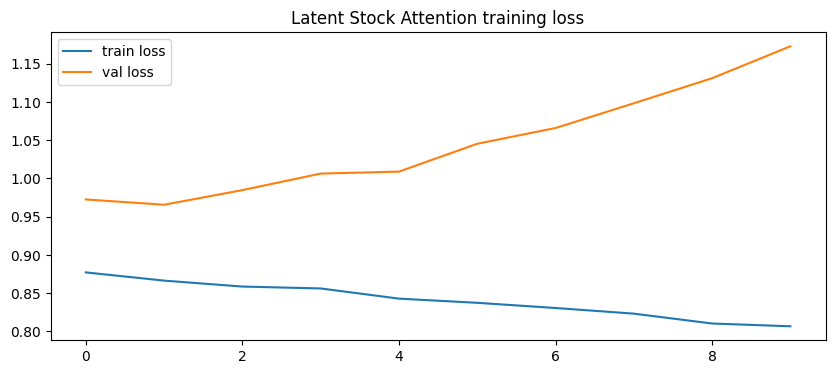

In [34]:
plt.figure(figsize=(10, 4))

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")

plt.legend()
plt.title("Latent Stock Attention training loss")
plt.show()

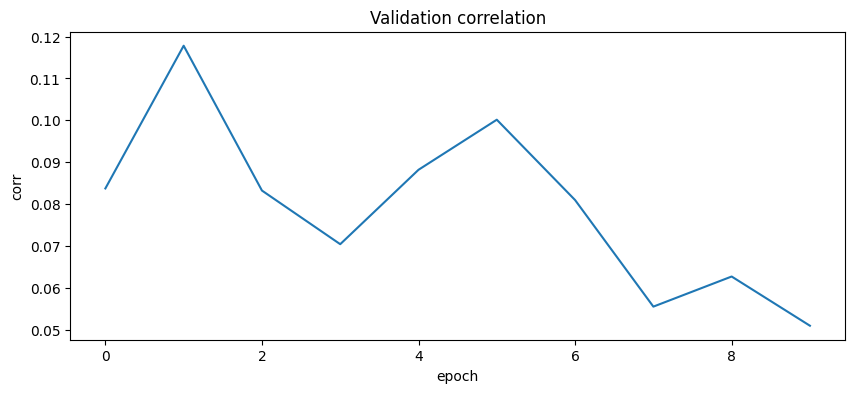

In [35]:
plt.figure(figsize=(10, 4))

plt.plot(history["val_corr"])

plt.title("Validation correlation")
plt.ylabel("corr")
plt.xlabel("epoch")
plt.show()

In [36]:
stock_attention_model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for zb, yb in test_loader:
        zb = zb.to(device)

        y_pred = stock_attention_model(zb)

        test_preds.append(y_pred.cpu().numpy())
        test_targets.append(yb.numpy())

test_preds = np.concatenate(test_preds, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

test_preds_unscaled = test_preds * y_std + y_mean
test_targets_unscaled = test_targets * y_std + y_mean

test_preds_unscaled.shape, test_targets_unscaled.shape

((698, 30), (698, 30))

In [37]:
test_corr = np.corrcoef(
    test_targets_unscaled.ravel(),
    test_preds_unscaled.ravel()
)[0, 1]

test_corr

np.float64(0.07752812117672084)

In [38]:
test_dates = market_dates[test_mask]

score_df = pd.DataFrame(
    test_preds_unscaled,
    index=test_dates,
    columns=tickers
)

score_df.head()

,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
2022-03-09,0.019449,0.016470,0.029585,0.038493,0.036055,0.029014,0.012417,0.015670,0.029267,0.017937,...,0.044801,0.039070,0.025529,0.011340,0.011751,0.039745,0.014262,0.028007,0.012185,0.030578
2022-03-10,0.020062,0.016197,0.029364,0.040059,0.037527,0.031238,0.013465,0.015728,0.030202,0.018377,...,0.046090,0.040361,0.025118,0.011510,0.011973,0.040641,0.014343,0.029164,0.012312,0.031095
2022-03-11,0.020698,0.016169,0.030001,0.040812,0.039698,0.031500,0.014257,0.014769,0.031541,0.019313,...,0.047097,0.040473,0.024901,0.011616,0.012192,0.041076,0.014456,0.030421,0.012525,0.033024
2022-03-14,0.021491,0.015910,0.030178,0.043541,0.041118,0.034939,0.015085,0.015202,0.032081,0.019911,...,0.047949,0.042573,0.025001,0.011788,0.012527,0.042441,0.014530,0.031371,0.012646,0.032907
2022-03-15,0.021022,0.016021,0.030729,0.043527,0.042346,0.035348,0.016044,0.014370,0.032958,0.020607,...,0.048523,0.042403,0.024684,0.011897,0.012480,0.042940,0.014388,0.031466,0.012739,0.034190


In [39]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    positions = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=score_df.columns
    )

    current_position = pd.Series(
        0.0,
        index=score_df.columns
    )

    for i, date in enumerate(score_df.index):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            if len(scores) == 0:
                positions.loc[date] = current_position
                continue

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(
                0.0,
                index=score_df.columns
            )

            new_position.loc[
                scores[scores >= long_threshold].index
            ] = 1.0

            new_position.loc[
                scores[scores <= short_threshold].index
            ] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [40]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(
        next_returns.index
    )

    common_cols = positions.columns.intersection(
        next_returns.columns
    )

    pos = positions.loc[
        common_index,
        common_cols
    ]

    ret = next_returns.loc[
        common_index,
        common_cols
    ]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)

    net = gross - transaction_cost * turnover

    return net, turnover

In [41]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1

    ann_return = (
        (1 + total_return) ** (252 / len(r))
        - 1
    )

    ann_vol = r.std() * np.sqrt(252)

    sharpe = (
        ann_return / ann_vol
        if ann_vol > 0
        else np.nan
    )

    equity = (1 + r).cumprod()

    drawdown = (
        equity / equity.cummax()
        - 1
    )

    max_drawdown = drawdown.min()

    return pd.Series(
        {
            "total_return": total_return,
            "ann_return": ann_return,
            "ann_vol": ann_vol,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
        }
    )

In [42]:
positions = build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

latent_attention_returns, latent_attention_turnover = portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

latent_attention_returns.name = "vae_latent_stock_attention"

performance_stats(latent_attention_returns)

total_return    0.183492
ann_return      0.062710
ann_vol         0.060798
sharpe          1.031453
max_drawdown   -0.063756
dtype: float64

In [43]:
latent_attention_turnover.mean()

np.float64(0.03247373447946514)

In [44]:
sup_backtest = pd.read_parquet(
    DATA_BACKTESTS / "supervised_vae_backtest_returns.parquet"
)

sup_backtest.index = pd.to_datetime(sup_backtest.index)

comparison = pd.concat(
    [
        sup_backtest["raw_feature_ridge"],
        sup_backtest["supervised_vae_direct"],
        latent_attention_returns,
    ],
    axis=1
).dropna()

stats = comparison.apply(performance_stats).T

stats.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
vae_latent_stock_attention,0.183492,0.062710,0.060798,1.031453,-0.063756
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181


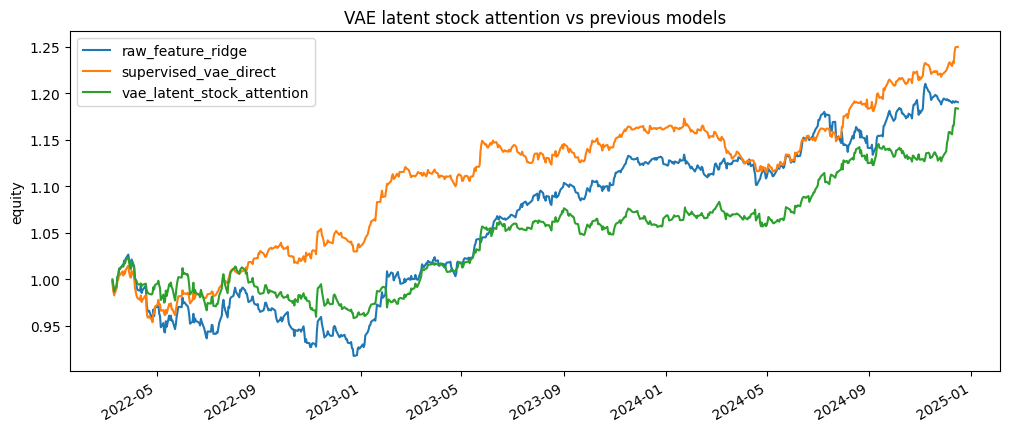

In [45]:
equity = (1 + comparison).cumprod()

equity.plot(
    figsize=(12, 5),
    title="VAE latent stock attention vs previous models"
)

plt.ylabel("equity")
plt.show()

In [46]:
comparison.to_parquet(
    DATA_BACKTESTS / "vae_latent_stock_attention_comparison_returns.parquet"
)

stats.to_csv(
    DATA_BACKTESTS / "vae_latent_stock_attention_comparison_stats.csv"
)

score_df.to_parquet(
    DATA_BACKTESTS / "vae_latent_stock_attention_scores.parquet"
)

In [47]:
stats

,total_return,ann_return,ann_vol,sharpe,max_drawdown
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
vae_latent_stock_attention,0.183492,0.062710,0.060798,1.031453,-0.063756


In [48]:
performance_stats(
    latent_attention_returns
)

total_return    0.183492
ann_return      0.062710
ann_vol         0.060798
sharpe          1.031453
max_drawdown   -0.063756
dtype: float64